In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="pastel")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

In [6]:
df_commits = pd.read_csv("../data/author_consistency_report.csv")
df_actions = pd.read_csv("../data/runs.csv")

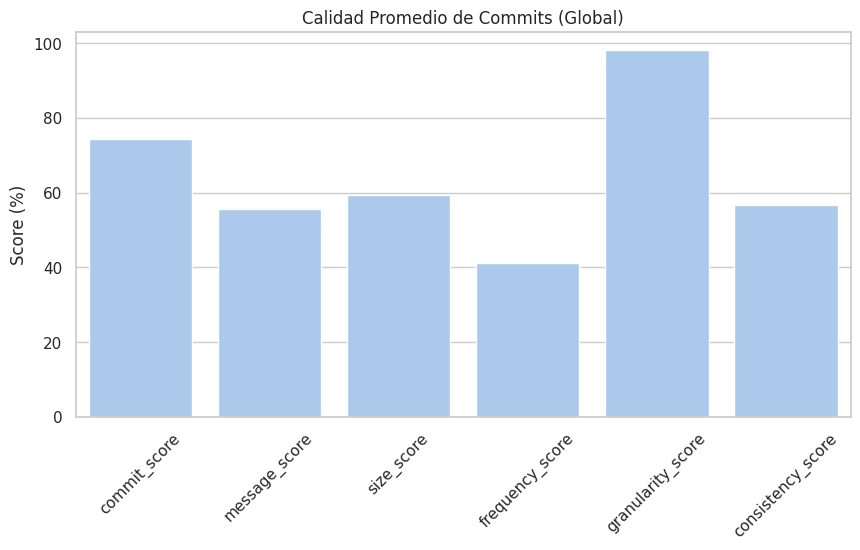

In [9]:
metricas = [
    "commit_score",
    "message_score",
    "size_score",
    "frequency_score",
    "granularity_score",
    "consistency_score"
]

promedios = df_commits[metricas].mean().reset_index()
promedios.columns = ["Metrica", "Score"]

sns.barplot(data=promedios, x="Metrica", y="Score")

plt.xticks(rotation=45)
plt.title("Calidad Promedio de Commits (Global)")
plt.ylabel("Score (%)")
plt.xlabel("")
plt.show()

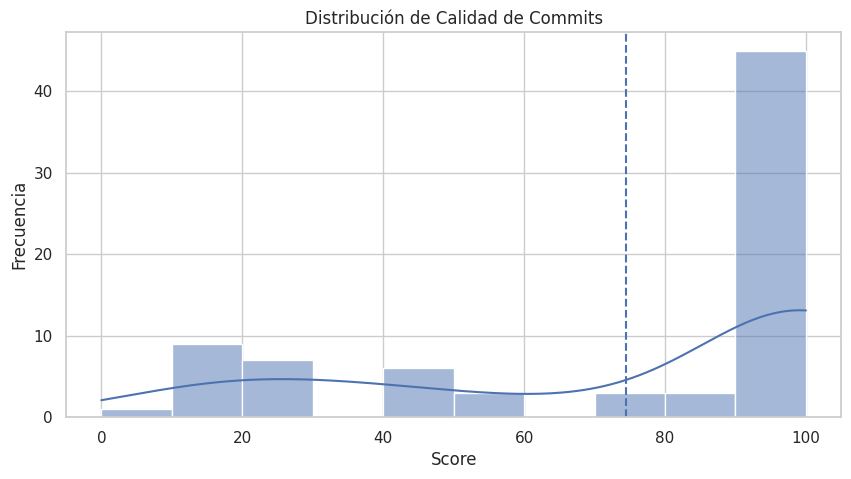

In [40]:
sns.histplot(
    df_commits["commit_score"],
    bins=10,
    kde=True
)

plt.axvline(df_commits["commit_score"].mean(), linestyle="--")
plt.title("Distribución de Calidad de Commits")
plt.xlabel("Score")
plt.ylabel("Frecuencia")

plt.show()

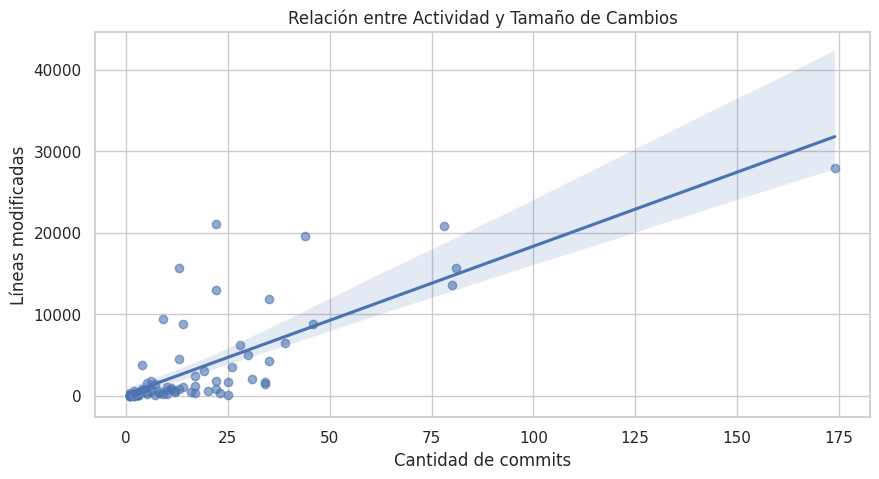

In [35]:
sns.regplot(
    data=df_commits,
    x="total_commits",
    y="total_lines_changed",
    scatter_kws={"alpha": 0.6}
)

plt.title("Relación entre Actividad y Tamaño de Cambios")
plt.xlabel("Cantidad de commits")
plt.ylabel("Líneas modificadas")

plt.show()

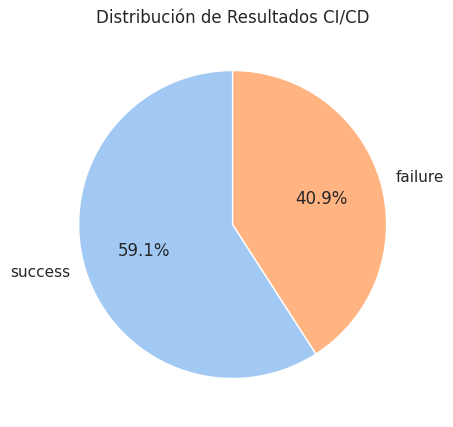

In [26]:
sns.set_theme(style="whitegrid")

# Contar resultados
estado = df_actions["conclusion"].value_counts()

# Etiquetas y valores
labels = estado.index
values = estado.values

colors = sns.color_palette("pastel")

plt.figure()

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

plt.title("Distribución de Resultados CI/CD")

plt.show()

In [30]:
success_rate = (df_actions["conclusion"] == "success").mean() * 100

print(f"Tasa de éxito CI/CD: {success_rate:.2f}%")

Tasa de éxito CI/CD: 59.11%


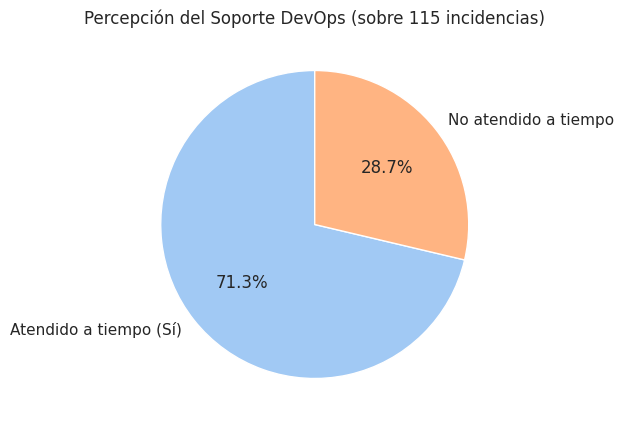

In [24]:
sns.set_theme(style="whitegrid")

# Datos escalados
labels = ["Atendido a tiempo (Sí)", "No atendido a tiempo"]
values = [82, 33]

plt.figure()

colors = sns.color_palette("pastel")[0:2]

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

plt.title("Percepción del Soporte DevOps (sobre 115 incidencias)")

plt.show()

In [29]:
calidad_global = df_commits[metricas].mean().mean()
success_rate = (df_actions["conclusion"] == "success").mean() * 100

score_global = (calidad_global * 0.8) + (success_rate * 0.4)

print(f"Indicador global DevOps: {score_global:.2f}%")

Indicador global DevOps: 74.99%


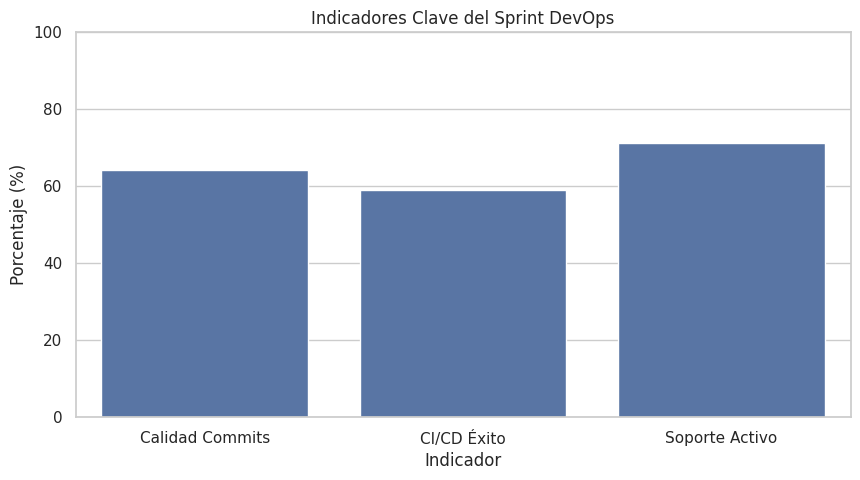

In [ ]:
resumen = pd.DataFrame({
    "Indicador": ["Calidad Commits", "CI/CD Éxito", "Soporte Activo"],
    "Valor": [calidad_global, success_rate, 71.3]
})

sns.barplot(data=resumen, x="Indicador", y="Valor")

plt.ylim(0, 100)
plt.title("Indicadores Clave del Sprint DevOps")
plt.ylabel("Porcentaje (%)")
plt.show()